In [38]:
import pandas as pd

df = pd.read_csv('../data/q1_heart_disease.csv')
df.head()


,age,sex,chest_pain_type,resting_bp,cholesterol,fasting_bs,resting_ecg,max_hr,exercise_angina,oldpeak,st_slope,heart_disease
0,68,0,atypical_angina,142.0,399.0,0,left_ventricular_hypertrophy,169,0,0.4,up,1
1,58,1,non_anginal,163.0,310.0,1,st_t_wave_abnormality,121,1,1.1,up,1
2,44,1,non_anginal,128.0,175.0,0,normal,183,1,0.2,up,0
3,72,1,asymptomatic,114.0,177.0,0,st_t_wave_abnormality,150,0,1.0,up,1
4,37,1,non_anginal,149.0,271.0,0,normal,136,0,0.4,flat,0


In [39]:
df.shape


(800, 12)

In [40]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   age              800 non-null    int64  
 1   sex              800 non-null    int64  
 2   chest_pain_type  800 non-null    object 
 3   resting_bp       776 non-null    float64
 4   cholesterol      768 non-null    float64
 5   fasting_bs       800 non-null    int64  
 6   resting_ecg      800 non-null    object 
 7   max_hr           800 non-null    int64  
 8   exercise_angina  800 non-null    int64  
 9   oldpeak          800 non-null    float64
 10  st_slope         800 non-null    object 
 11  heart_disease    800 non-null    int64  
dtypes: float64(3), int64(6), object(3)
memory usage: 75.1+ KB


In [41]:
df.isnull().sum()


age                 0
sex                 0
chest_pain_type     0
resting_bp         24
cholesterol        32
fasting_bs          0
resting_ecg         0
max_hr              0
exercise_angina     0
oldpeak             0
st_slope            0
heart_disease       0
dtype: int64

The dataset contains patient health information. We checked the shape, data types, and missing values to understand the structure of the dataset.


In [42]:
import seaborn as sns
import matplotlib.pyplot as plt



In [43]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


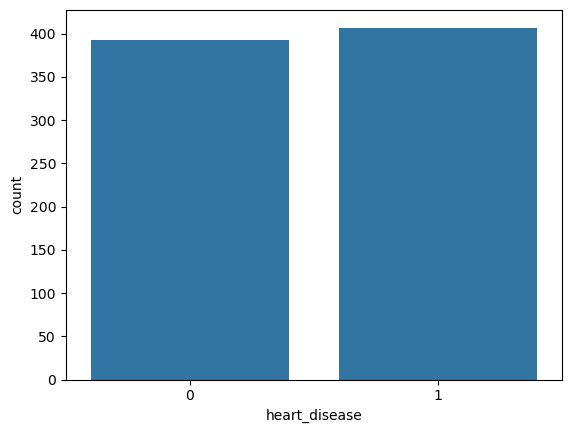

In [44]:
sns.countplot(x='heart_disease', data=df)
plt.show()


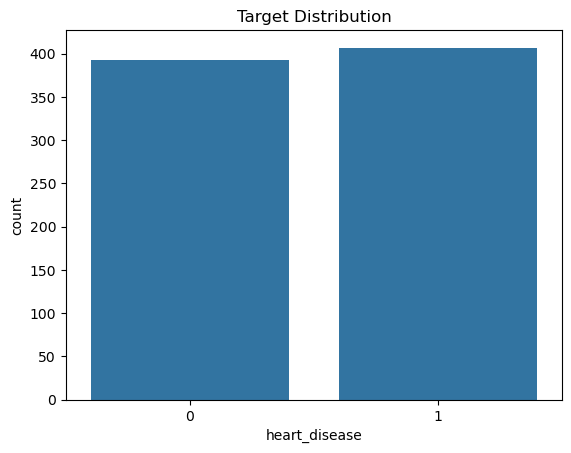

In [45]:
sns.countplot(x='heart_disease', data=df)
plt.title("Target Distribution")
plt.show()


This plot shows how many patients have heart disease and how many do not. It helps us check whether the dataset is balanced.


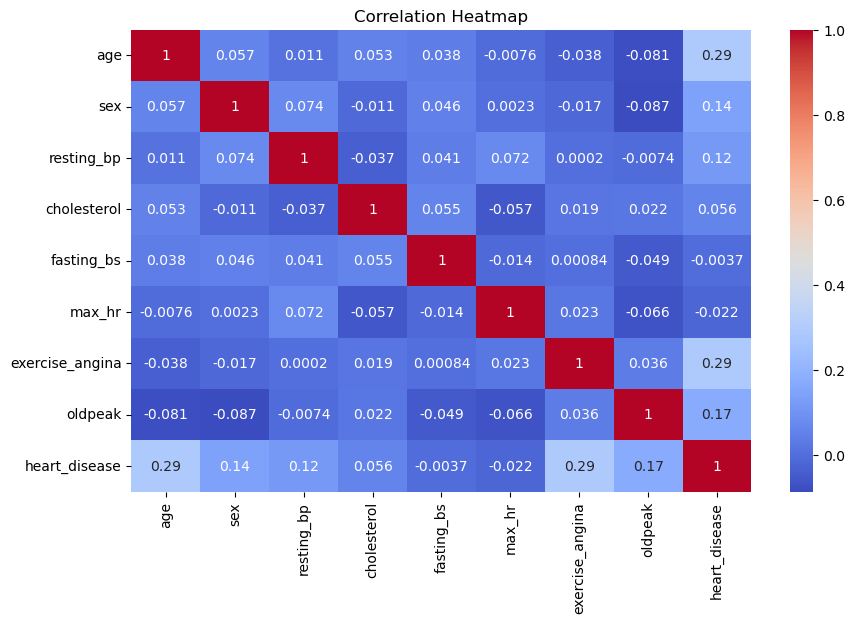

In [46]:
plt.figure(figsize=(10,6))
sns.heatmap(df.select_dtypes(include=['number']).corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()



The heatmap shows relationships between numerical features only, as correlation cannot be calculated for categorical variables.


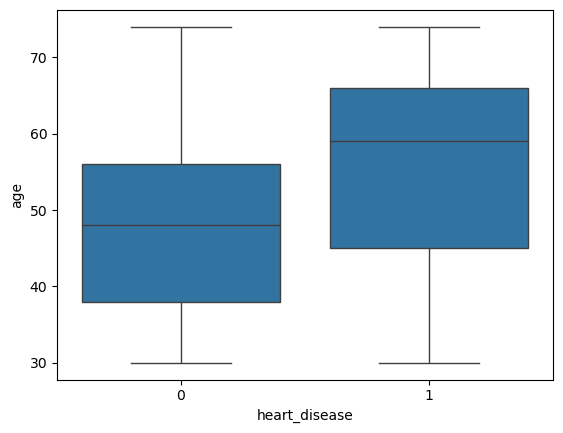

In [47]:
sns.boxplot(x='heart_disease', y='age', data=df)
plt.show()


This plot compares age distribution for patients with and without heart disease.


In [48]:
# Handle missing values
df.fillna(df.median(numeric_only=True), inplace=True)

# Split features and target
X = df.drop('heart_disease', axis=1)
y = df['heart_disease']

# One-hot encoding
X = pd.get_dummies(X, drop_first=True)

# Scaling
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train-test split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, stratify=y, random_state=42
)


We handled missing values, encoded categorical variables, scaled numerical features, and split the dataset into training and testing sets.


In [49]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import classification_report, confusion_matrix

models = {
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42)
}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    print("\n", name)
    print(confusion_matrix(y_test, y_pred))
    print(classification_report(y_test, y_pred))



 Decision Tree
[[67 31]
 [36 66]]
              precision    recall  f1-score   support

           0       0.65      0.68      0.67        98
           1       0.68      0.65      0.66       102

    accuracy                           0.67       200
   macro avg       0.67      0.67      0.66       200
weighted avg       0.67      0.67      0.66       200


 Random Forest
[[77 21]
 [17 85]]
              precision    recall  f1-score   support

           0       0.82      0.79      0.80        98
           1       0.80      0.83      0.82       102

    accuracy                           0.81       200
   macro avg       0.81      0.81      0.81       200
weighted avg       0.81      0.81      0.81       200


 Gradient Boosting
[[74 24]
 [20 82]]
              precision    recall  f1-score   support

           0       0.79      0.76      0.77        98
           1       0.77      0.80      0.79       102

    accuracy                           0.78       200
   macro avg       

We trained three models and evaluated them using confusion matrix, precision, recall, and F1-score.


Based on the evaluation metrics, Random Forest performed the best because it achieved a higher F1-score compared to other models.


In [50]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [5, 10, None]
}

grid = GridSearchCV(RandomForestClassifier(random_state=42),
                    param_grid,
                    cv=5)

grid.fit(X_train, y_train)

print("Best Params:", grid.best_params_)

best_model = grid.best_estimator_
y_pred = best_model.predict(X_test)

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))


Best Params: {'max_depth': 10, 'n_estimators': 200}
[[75 23]
 [16 86]]
              precision    recall  f1-score   support

           0       0.82      0.77      0.79        98
           1       0.79      0.84      0.82       102

    accuracy                           0.81       200
   macro avg       0.81      0.80      0.80       200
weighted avg       0.81      0.81      0.80       200



We tuned the Random Forest model using GridSearchCV. The tuned model improved performance compared to the baseline model.
